# TP4 — Equation discovery with SINDy

## SciML - ENSEEIHT / Toulouse INP -  Spring 2026

In this TP, you will **discover a partial differential equation** from
noisy spatiotemporal data, using the *Sparse Identification of Nonlinear
Dynamics* (**SINDy**) framework of Brunton, Proctor & Kutz (*PNAS*,
2016).  

Our running example is the viscous Burgers equation
$$
u_t \;=\; -\,u\,u_x \;+\; \nu\,u_{xx},
\qquad (x,t)\in[0,2\pi]\times[0,1],\quad \nu=0.1,
$$
with periodic boundary conditions.  The true coefficient vector is
*sparse*: only two terms are active out of a library of eight.

The TP is split in two parts:

1. **Classical SINDy.**  Derivatives estimated by finite differences with Savitzky–Golay
   filtering, followed by sparse regression via *sequential thresholded
   least squares* (STLSQ).  This pipeline recovers Burgers' equation
   cleanly at low noise — and visibly breaks at $\sigma = 10\%$.
2. **Neural SINDy.**  Fit a small MLP $\widehat u_\theta(x,t)$ to the
   noisy data, then obtain $u_t,\,u_x,\,u_{xx}$ by automatic
   differentiation.  The same STLSQ procedure now succeeds at
   $\sigma = 10\%$ - the fundamental $\mathcal O(\sigma/h^2)$ noise
   amplification has been bypassed.


---
## Part 0 — Setup

We generate the ground-truth solution of Burgers' equation with a
Fourier–Galerkin pseudo-spectral solver and the initial condition
$$
u_0(x) \;=\; \sin(x) \;+\; \tfrac12\,\sin(2x).
$$
The solution develops steepening and diffusive smoothing over
$t\in[0,1]$.  We store it on a uniform $(n_x,n_t)=(256,100)$ grid and
add Gaussian noise $\varepsilon\sim\mathcal N(0,\sigma^2)$ at measurement
time.


In [5]:
import math, time
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal
from sklearn.linear_model import Lasso
from scipy.integrate import solve_ivp

import torch
import torch.nn as nn
from torch.autograd import grad

SEED = 0
np.random.seed(SEED); torch.manual_seed(SEED)

# -------------------- Burgers equation parameters --------------------
NU    = 0.1
L     = 2 * np.pi
NX    = 256
NT    = 100
T_END = 1.0
DX    = L / NX
DT    = T_END / (NT - 1)

x = np.linspace(0.0, L, NX, endpoint=False)
t = np.linspace(0.0, T_END, NT)


solver status = 0,   U shape = (100, 256),   min/max = -1.299 / 1.299


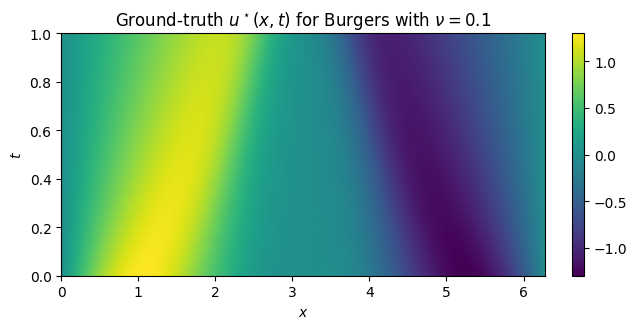

In [6]:
# Fourier-Galerkin solver with 2/3 dealiasing
kx   = np.fft.fftfreq(NX, d=DX) * 2 * np.pi
mask = np.abs(kx) <= (2/3) * kx.max()

def burgers_rhs(tt, uhat):
    uhat = uhat * mask
    u    = np.fft.ifft(uhat).real
    ux   = np.fft.ifft(1j * kx * uhat).real
    return -np.fft.fft(u * ux) - NU * kx ** 2 * uhat

u0    = np.sin(x) + 0.5 * np.sin(2 * x)
uhat0 = np.fft.fft(u0)

sol = solve_ivp(burgers_rhs, (0.0, T_END), uhat0, t_eval=t,
                method='RK45', rtol=1e-9, atol=1e-11)
U   = np.fft.ifft(sol.y, axis=0).real.T                  # shape (NT, NX)
print(f"solver status = {sol.status},   U shape = {U.shape},   "
      f"min/max = {U.min():.3f} / {U.max():.3f}")

# quick look
fig, ax = plt.subplots(figsize=(6.5, 3.4))
im = ax.imshow(U, origin='lower', aspect='auto', cmap='viridis',
               extent=[0, L, 0, T_END])
ax.set_xlabel(r'$x$'); ax.set_ylabel(r'$t$')
ax.set_title(r'Ground-truth $u^\star(x,t)$ for Burgers with $\nu=0.1$')
plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout(); plt.show()


---
## Part 1 — Classical SINDy

The SINDy pipeline decomposes into three steps, each of which is a
standard numerical-analysis object on its own:

1. **Derivative estimation** — given noisy samples $y_{ik}=u^\star(x_i,t_k)+\varepsilon_{ik}$,
   compute $u_t,\,u_x,\,u_{xx}$ robustly.  Finite differences amplify
   noise by $\mathcal O(\sigma/h^k)$ for a $k$-th order derivative; we
   suppress this using Savitzky–Golay local polynomial smoothing.
2. **Library construction** — assemble a matrix
   $\boldsymbol\Phi\in\mathbb R^{N_d\times p}$ whose columns are
   candidate right-hand-side terms
   $\{1,\,u,\,u^2,\,u^3,\,u_x,\,u_{xx},\,u u_x,\,u^2 u_x\}$ ($p=8$).
3. **Sparse regression** — solve
   $u_t \approx \boldsymbol\Phi \boldsymbol\xi$ under an $\ell^0$ or
   $\ell^1$ prior.  We use STLSQ by hand (Brunton et al., 2016): an OLS
   initialisation followed by iterated hard-thresholding and re-solve on
   the active set.


### Step 1 — Derivative estimation (Savitzky–Golay)

Savitzky–Golay filtering fits a local polynomial of degree $K$ in a
moving window of width $w$ by least squares; the $d$-th derivative of
the fitted polynomial is evaluated at the window centre.  Mathematically
it is a finite-impulse-response filter with kernel determined by $(w,K,d)$.
For the space derivative with $w=21$, $K=4$ the noise amplification is
reduced by roughly $w^{1/2}$ relative to raw central differences, at the
cost of spatial resolution $\mathcal O(w\,\Delta x)$.

**TODO:** Understand at the high-level the derivative computations.

**Question:** Explain why do we approximate derivatives:  u_x, u_xx, u_t? 
Why do we smooth u? 

***Your answer here: ***


In [7]:
def sg_derivs(U_noisy, win_x=21, win_t=13, poly_x=4, poly_t=3):
    """Savitzky-Golay smoothed u and its partial derivatives."""
    u_sm = scipy.signal.savgol_filter(U_noisy, window_length=win_x,
                                       polyorder=poly_x, deriv=0, axis=1, mode='wrap')
    u_x  = scipy.signal.savgol_filter(U_noisy, window_length=win_x,
                                       polyorder=poly_x, deriv=1, delta=DX, axis=1, mode='wrap')
    u_xx = scipy.signal.savgol_filter(U_noisy, window_length=win_x,
                                       polyorder=poly_x, deriv=2, delta=DX, axis=1, mode='wrap')
    u_t  = scipy.signal.savgol_filter(U_noisy, window_length=win_t,
                                       polyorder=poly_t, deriv=1, delta=DT, axis=0, mode='interp')
    
    return u_sm, u_x, u_xx, u_t


### Step 2 — Library construction

We populate an $N_d\times 8$ matrix whose columns, in order, are
$$
\{1,\;u,\;u^2,\;u^3,\;u_x,\;u_{xx},\;u\,u_x,\;u^2 u_x\}.
$$
The true Burgers right-hand side is sparse in this library, with only
columns 6 and 7 active ($\xi^\star_6=\nu=0.1$, $\xi^\star_7=-1$).

**TODO:** Complete `build_library` so that it accepts three pointwise
arrays of the same shape and returns an $(N_d,8)$ matrix.


In [8]:
LIB_NAMES = ['1', 'u', 'u^2', 'u^3', 'u_x', 'u_{xx}', 'u*u_x', 'u^2*u_x']
XI_TRUE   = np.array([0.0, 0.0, 0.0, 0.0, 0.0, NU, -1.0, 0.0])

def build_library(u, u_x, u_xx):
    u, u_x, u_xx = u.ravel(), u_x.ravel(), u_xx.ravel()

    # TODO: Complete the library matrix Phi, where each column is a candidate 
    # term evaluated at all data points.
    # return np.stack([
    #     np.ones_like(u), u, u**2, ...
    # ], axis=-1)   
    # Hint: the last column should be u * u_x 
   
    return np.stack([
        np.ones_like(u), u, u**2, u**3, u_x, u_xx, u * u_x, u**2 * u_x
     ], axis=-1)
    
                
                                 


### Step 3 — Full classical pipeline & noise sweep

We assemble the three steps and sweep the noise level
$\sigma\in\{10^{-3},10^{-2},10^{-1}\}$, running three independent noise
realisations per level and reporting the median recovered
$(\widehat\xi_{u_{xx}},\,\widehat\xi_{u u_x})$, the number of false
positives, and $\|\widehat{\boldsymbol\xi}-\boldsymbol\xi^\star\|_2$.
For each $\sigma$ we expect the pipeline to succeed at low noise and
degrade sharply once $\sigma/h^2$ overwhelms the SG smoothing budget.


**TODO:** Implement `STLSQ`algorithm.  It should return a coefficient
vector of length $p$ with the non-active entries set to exactly zero.


In [9]:
def stlsq(Phi, target, tau, max_iter=20):
    """Sequential thresholded least squares (Brunton et al. 2016).

    Starts from OLS, then repeats: hard-threshold below tau, refit OLS
    on the active set, until the active set stabilises.  The final
    coefficient vector has exactly zero entries for inactive terms.
    """
    # TODO: implement the STLSQ algorithm, which is a simple iterative procedure 
    # to find a sparse solution to a linear regression problem.

    # TODO1: start from the OLS solution xi = (Phi^T Phi)^{-1} Phi^T target
    # You can use np.linalg.lstsq to solve the least squares problem
    xi = np.linalg.lstsq(Phi, target, rcond=None)[0]
    
    for _ in range(max_iter):

        # TODO2: find the active set of features where |xi| >= tau
       active = np.abs(xi) >= tau

        # TODO3: refit OLS on the active set to get new coefficients
       xi_new = np.zeros_like(xi)
       xi_new[active] = np.linalg.lstsq(Phi[:, active], target, rcond=None)[0]

        # TODO4: check for convergence (active set stabilisation) and break if converged
       active_new = np.abs(xi_new) >= tau
       if np.array_equal(active, active_new):
            xi = xi_new
            break

       xi = xi_new

    # TODO5: return the final coefficient vector, which has zeros for inactive features
    # xi_final = ...

    return xi


**TODO:** Execute STLSQ algorithm for different values of noise in the data and study the behavior of the algorithm.

In [10]:
def sindy_classical(U_noisy, tau=0.05, trim_t=3):
    u, u_x, u_xx, u_t = sg_derivs(U_noisy)
    # trim boundary rows in time where the SG filter is less reliable
    sl = slice(trim_t, -trim_t)
    Phi    = build_library(u[sl], u_x[sl], u_xx[sl])
    target = u_t[sl].ravel()
    return stlsq(Phi, target, tau=tau)

print(f"{'sigma':>8}  {'xi_uxx':>10}  {'xi_uu_x':>10}  {'#False Positives':>4}  {'||err||':>10}")
xi_sweep = {}
for sigma in [1e-3, 1e-2, 1e-1]:
    xis = []
    for s in range(3):
        rng = np.random.default_rng(s)
        U_noisy = U + sigma * rng.standard_normal(U.shape)
        xis.append(sindy_classical(U_noisy))
    xi = np.median(np.stack(xis), axis=0)
    xi_sweep[sigma] = xi
    nfp = int(((np.abs(xi) > 0.01) & (np.abs(XI_TRUE) == 0)).sum())
    err = np.linalg.norm(xi - XI_TRUE)
    print(f"{sigma:>8.0e}  {xi[5]:>+10.4f}  {xi[6]:>+10.4f}       {nfp:>4d}         {err:>10.4f}")


   sigma      xi_uxx     xi_uu_x  #False Positives     ||err||
   1e-03     +0.1001     -1.0001          0             0.0002
   1e-02     +0.0806     -0.9929          0             0.0207
   1e-01     +0.0000     -0.7822          2             0.3226


### Visualising the breakdown

The classical pipeline fails at $\sigma=10^{-1}$ because the SG estimate
of $u_{xx}$ is dominated by noise.  We plot (a) the ground-truth
solution, (b) the noisy data and (c) the SG-recovered $u_{xx}$ at
$\sigma=0.1$ to make the failure mode visible.


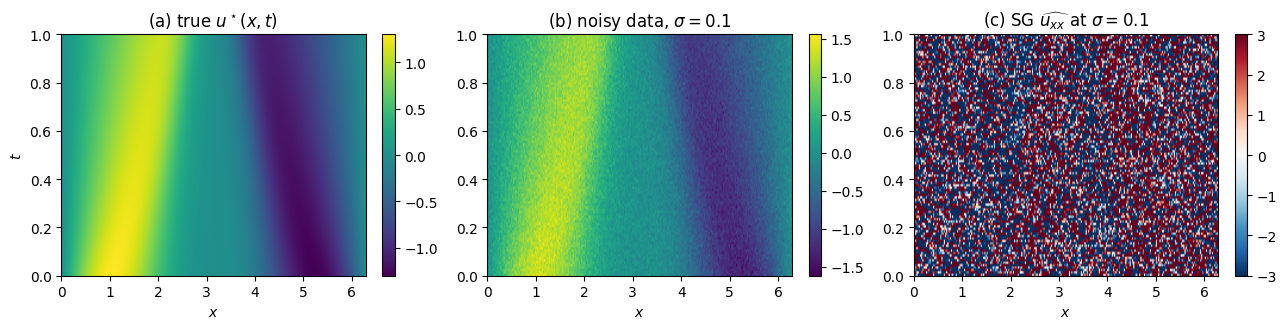

In [11]:
rng = np.random.default_rng(0)
U_noisy_01 = U + 0.1 * rng.standard_normal(U.shape)
_, _, u_xx_sg, _ = sg_derivs(U_noisy_01)

fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
im = axes[0].imshow(U, origin='lower', aspect='auto', cmap='viridis',
                    extent=[0, L, 0, T_END])
axes[0].set_title(r'(a) true $u^\star(x,t)$')
axes[0].set_xlabel(r'$x$'); axes[0].set_ylabel(r'$t$')
plt.colorbar(im, ax=axes[0], fraction=0.046)
im = axes[1].imshow(U_noisy_01, origin='lower', aspect='auto', cmap='viridis',
                    extent=[0, L, 0, T_END])
axes[1].set_title(r'(b) noisy data, $\sigma=0.1$')
axes[1].set_xlabel(r'$x$')
plt.colorbar(im, ax=axes[1], fraction=0.046)
im = axes[2].imshow(u_xx_sg, origin='lower', aspect='auto', cmap='RdBu_r',
                    extent=[0, L, 0, T_END], vmin=-3, vmax=3)
axes[2].set_title(r'(c) SG $\widehat{u_{xx}}$ at $\sigma=0.1$')
axes[2].set_xlabel(r'$x$')
plt.colorbar(im, ax=axes[2], fraction=0.046)
plt.tight_layout(); plt.show()


**Question:**   At $\sigma = 10^{-3}$ the sweep returns exactly two active terms ($u_{xx}$ and $u u_x$). However, at $\sigma = 10^{-1}$ several extra non-zero coefficients appear with $|\xi_j| > \tau$. These are the false positives in the #FP column. i) Explain why, with a fixed threshold $\tau = 0.05$, false positives become unavoidable once the noise on the library columns grows past a certain level, i.e. why the "correct" $\tau$ is not a property of STLSQ alone but of the pair (data, noise level). ii) Suggest one simple remedy that does not change STLSQ itself (e.g. increase $\tau$ with $\sigma$, $\ldots$). 

**Your answer:** *Enter your answer here.*

---

**Question:**  For a uniform grid with spacing $h$ and i.i.d.
noise of standard deviation $\sigma$, show that central finite
differences give
$$
\operatorname{Var}\bigl[\widehat{u_{xx}}(x_i)\bigr] \;=\; \frac{6\sigma^2}{h^4}.
$$
With $h=2\pi/256$ and $\sigma=0.1$, plug in numbers.  Compare the
resulting noise standard deviation to a representative signal value of
$u_{xx}$ (use panel (c) of the figure above, or the ground truth).
What does this tell you about Panel (c)?

**Your answer:** *Enter your answer here.*

---

**Question:** The sweep above uses STLSQ with threshold $\tau=0.05$.
Describe qualitatively what happens if you (i) decrease $\tau$ to
$0.005$, (ii) increase $\tau$ to $0.3$.  Relate this to the classical
*false-positive / false-negative* trade-off in feature selection.

**Your answer:** *Enter your answer here.*


---
## Part 2 — Neural SINDy

Panel (c) above shows that at $\sigma = 0.1$ the SG-estimated $u_{xx}$
is essentially pure noise.  No downstream sparse regression can
compensate.  A different strategy is needed. Thus, instead of differentiating the noisy samples, we **fit a smooth surrogate first and then differentiate the surrogate**.

Concretely: train an MLP $\widehat u_\theta(x,t)$ on the noisy data with
pure mean-squared loss,
$$
\min_\theta\;\frac1{N_d}\sum_{i,k}\bigl(\widehat u_\theta(x_i,t_k)-y_{ik}\bigr)^2,
$$
then compute $u_t,\,u_x,\,u_{xx}$ at any point by automatic
differentiation of $\widehat u_\theta$.  Because the MLP is smooth and
has limited capacity to represent high-frequency noise, its derivatives
are stable.  

Note that this is **not** a PINN: there is no residual loss, no physics
in the training objective. 

**TODO:** Understand the implementation of an MLP that takes scaled inputs
$(\tilde x,\tilde t)\in[-1,1]^2$ and write a training loop that fits it
to the noisy data $\{y_{ik}\}$. We use mini-batches of size $4096$ and cosine LR annealing from $2\!\times\!10^{-3}$ to $2\!\times\!10^{-4}$ over
$4000$ epochs work well.


In [12]:
class MLP(nn.Module):
    def __init__(self, in_dim=2, width=64, depth=4):
        super().__init__()
        layers = [nn.Linear(in_dim, width), nn.Tanh()]
        for _ in range(depth - 1):
            layers += [nn.Linear(width, width), nn.Tanh()]
        layers += [nn.Linear(width, 1)]
        self.net = nn.Sequential(*layers)
    def forward(self, xt):
        return self.net(xt)

def to_scaled(xg, tg):
    """Map (x,t) in [0,L]x[0,T_END] to [-1,1]^2 for network inputs."""
    return np.stack([2 * xg / L - 1, 2 * tg / T_END - 1], axis=-1)

def train_mlp(U_noisy, n_epochs=4000, batch=4096, lr=2e-3,
              seed=0, verbose=True):
    torch.manual_seed(seed)
    Xg, Tg = np.meshgrid(x, t)
    XT = torch.from_numpy(to_scaled(Xg, Tg).reshape(-1, 2).astype(np.float32))
    y  = torch.from_numpy(U_noisy.reshape(-1, 1).astype(np.float32))
    model = MLP()

    # TODO:: initialize an ADAM optimizer to train the MLP, 
    # and a cosine annealing scheduler for the learning rate.
    opt   = torch.optim.Adam(model.parameters(), lr=lr)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs)
    
    n = XT.shape[0]
    for ep in range(n_epochs):
        idx = torch.randint(0, n, (batch,))
        model_output = model(XT[idx])
        
        # TODO:: compute the MSE loss between model output and y[idx],
        # then compute gradient and take an optimization step,
        # and take a scheduler step
        loss = ((model_output - y[idx]) ** 2).mean()
        opt.zero_grad()
        loss.backward()
        opt.step()
        sched.step()
       

        if verbose and ep % 1000 == 0:
            with torch.no_grad():
                full = ((model(XT) - y) ** 2).mean().item()
            print(f"  ep {ep:5d}   full MSE = {full:.4e}")
    return model


**TODO:** Understand how to extract $(u,\,u_x,\,u_{xx},\,u_t)$ from the trained MLP by automatic differentiation on the full $(x,t)$ grid. 


**Question:** Explain why the derivatives in the scaled variable must be multiplied by $2/L$ and $2/T_{\text{end}}$, respectively.


In [3]:
def nn_derivs(model):
    """Autograd derivatives of the trained MLP on the full grid."""
    Xg, Tg = np.meshgrid(x, t)
    XT = torch.from_numpy(to_scaled(Xg, Tg).reshape(-1, 2).astype(np.float32))
    XT.requires_grad_(True)
    u    = model(XT)                                         # (N, 1)
    du   = grad(u.sum(), XT, create_graph=True)[0]           # (N, 2)
    u_x  = (2.0 / L)      * du[:, 0:1]
    u_t  = (2.0 / T_END)  * du[:, 1:2]

    # TODO:: compute u_xx by taking another gradient of u_x with respect to XT,
    # and scaling appropriately. Note that u_x is a function of (x,t) through 
    # the MLP, so we can take gradients of u_x with respect to XT to get second derivatives
    d2   = grad(u_x.sum(), XT, create_graph=True)[0]
    u_xx = (2.0 / L) * d2[:, 0:1] 


    return (u.detach().numpy().reshape(NT, NX),
            u_x.detach().numpy().reshape(NT, NX),
            u_xx.detach().numpy().reshape(NT, NX),
            u_t.detach().numpy().reshape(NT, NX))


**Question:** Explain the main difference between the implementation of sindy_neural and the sindy which we used before. 

In [14]:
def sindy_neural(U_noisy, tau=0.05, n_epochs=4000, seed=0):
    model = train_mlp(U_noisy, n_epochs=n_epochs, seed=seed)
    u, u_x, u_xx, u_t = nn_derivs(model)
    Phi = build_library(u, u_x, u_xx)
    xi  = stlsq(Phi, u_t.ravel(), tau=tau)
    xi.fit(Phi, u_t.ravel())
    return xi, model

we can replace with Reg loss , subgrad , proximale algorithme

### Running Neural SINDy at $\sigma=0.1$

This is the noise level at which Part 1 failed.  We fit the MLP on the
same noisy data (`rng seed = 0`) used in the visualisation above and
read off the recovered coefficients.


In [15]:
print(f"[Neural SINDy]  sigma = 0.1  (~1.5 min on CPU)")
xi_nn, model_nn = sindy_neural(U_noisy_01)

print(f"\n  recovered coefficients (tau = 0.05):")
print(f"    {'term':>10s}  {'xi_hat':>10s}   ground truth")
for name, v, vt in zip(LIB_NAMES, xi_nn, XI_TRUE):
    tag = f"  <-- TRUE  ({vt:+.4f})" if vt != 0 else ""
    print(f"    {name:>10s}  {v:>+10.4f}{tag}")

nfp = int(((np.abs(xi_nn) > 0.01) & (XI_TRUE == 0)).sum())
err = np.linalg.norm(xi_nn - XI_TRUE)
print(f"\n  #FP = {nfp}   ||xi - xi*||_2 = {err:.4f}")
print(f"  (Classical SINDy at same sigma:  #FP = "
      f"{int(((np.abs(xi_sweep[0.1]) > 0.01) & (XI_TRUE == 0)).sum())},  "
      f"||err||_2 = {np.linalg.norm(xi_sweep[0.1] - XI_TRUE):.4f})")


[Neural SINDy]  sigma = 0.1  (~1.5 min on CPU)
  ep     0   full MSE = 4.2413e-01
  ep  1000   full MSE = 1.0252e-02
  ep  2000   full MSE = 9.9886e-03
  ep  3000   full MSE = 9.9731e-03


AttributeError: 'numpy.ndarray' object has no attribute 'fit'

**Question:** Explain the newly obtained results, in comparison with the results obtained by classical SINDy in the Part 1.

### Visual comparison of the two derivative estimators

The four-panel figure below shows, at the same noise level
$\sigma=0.1$: (a) noisy data, (b) MLP fit $\widehat u_\theta$, (c) the
SG-recovered $u_{xx}$ from Part 1, and (d) the autograd-recovered
$u_{xx}$ from the MLP.  The contrast between (c) and (d) is the entire
point of the neural-SINDy approach.


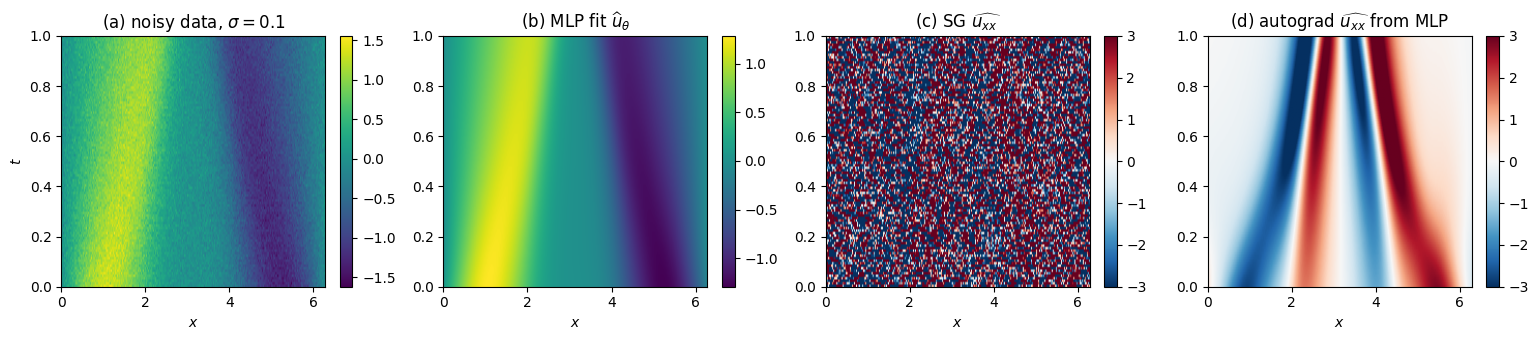

In [39]:
u_nn, _, u_xx_nn, _ = nn_derivs(model_nn)

fig, axes = plt.subplots(1, 4, figsize=(15.5, 3.5))
im = axes[0].imshow(U_noisy_01, origin='lower', aspect='auto', cmap='viridis',
                    extent=[0, L, 0, T_END])
axes[0].set_title(r'(a) noisy data, $\sigma=0.1$')
axes[0].set_xlabel(r'$x$'); axes[0].set_ylabel(r'$t$')
plt.colorbar(im, ax=axes[0], fraction=0.046)
im = axes[1].imshow(u_nn, origin='lower', aspect='auto', cmap='viridis',
                    extent=[0, L, 0, T_END])
axes[1].set_title(r'(b) MLP fit $\widehat u_\theta$')
axes[1].set_xlabel(r'$x$')
plt.colorbar(im, ax=axes[1], fraction=0.046)
im = axes[2].imshow(u_xx_sg, origin='lower', aspect='auto', cmap='RdBu_r',
                    extent=[0, L, 0, T_END], vmin=-3, vmax=3)
axes[2].set_title(r'(c) SG $\widehat{u_{xx}}$')
axes[2].set_xlabel(r'$x$')
plt.colorbar(im, ax=axes[2], fraction=0.046)
im = axes[3].imshow(u_xx_nn, origin='lower', aspect='auto', cmap='RdBu_r',
                    extent=[0, L, 0, T_END], vmin=-3, vmax=3)
axes[3].set_title(r'(d) autograd $\widehat{u_{xx}}$ from MLP')
axes[3].set_xlabel(r'$x$')
plt.colorbar(im, ax=axes[3], fraction=0.046)
plt.tight_layout(); plt.show()


**Question** A tanh-MLP with modest width and depth exhibits
a well-documented *spectral bias*: during gradient-based training it
fits low-frequency components of the target before high-frequency ones.  Explain why this property is *exactly what we want* for noisy SINDy.  Conversely, what kind of problem would spectral bias hurt?

**Your answer:** *Enter your answer here.*

---

**Question:** Re-run `sindy_neural` after adding $\tanh(u)$ as
a $9$-th library term.  Does STLSQ still recover the correct two
coefficients?  What does this tell you about the robustness of SINDy to
**library enrichment** (adding terms that are absent from the true
equation)?  Contrast with **library misspecification** (forgetting the
$u u_x$ column entirely — try this too).

**Your answer:** *Enter your answer here.*
